# Lecture 6: Table Review and the Census
v.ekc

Today is a workout day: we review every table move you've learned on two real datasets, our own class survey, and the U.S. Census.

**Today's sections:**
1. Reading a table from a file — Du Bois, continued
2. Table review — welcome survey
3. Census data
4. 2019 sex ratios and our first line plot

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

---
## 1. Reading a Table from a File — Du Bois, continued

Picking up the Du Bois dataset from last time (slide 5?), watch how arithmetic on columns builds new columns ooooo

In [16]:
du_bois = Table.read_table('du_bois.csv')
du_bois

CLASS,ACTUAL AVERAGE,RENT,FOOD,CLOTHES,TAXES,OTHER,STATUS
100-200,139.1,0.19,0.43,0.28,0.001,0.099,POOR
200-300,249.45,0.22,0.47,0.23,0.04,0.04,POOR
300-400,335.66,0.23,0.43,0.18,0.045,0.115,FAIR
400-500,433.82,0.18,0.37,0.15,0.055,0.245,FAIR
500-750,547,0.13,0.31,0.17,0.05,0.34,COMFORTABLE
750-1000,880,0,0.37,0.19,0.08,0.36,COMFORTABLE
1000 and over,1125,0,0.29,0.16,0.045,0.505,WELL-TO-DO


Pull the two ingredient columns out as arrays:

In [17]:
du_bois.column('ACTUAL AVERAGE')

array([  139.1 ,   249.45,   335.66,   433.82,   547.  ,   880.  ,  1125.  ])

In [18]:
du_bois.column('FOOD')

array([ 0.43,  0.47,  0.43,  0.37,  0.31,  0.37,  0.29])

Arrays multiply elementwise, so proportion of income × income = dollars:

In [19]:
food_dollars = du_bois.column('ACTUAL AVERAGE') * du_bois.column('FOOD')
food_dollars

array([  59.813 ,  117.2415,  144.3338,  160.5134,  169.57  ,  325.6   ,
        326.25  ])

In [20]:
du_bois = du_bois.with_column('Food $', food_dollars)
du_bois

CLASS,ACTUAL AVERAGE,RENT,FOOD,CLOTHES,TAXES,OTHER,STATUS,Food $
100-200,139.1,0.19,0.43,0.28,0.001,0.099,POOR,59.813
200-300,249.45,0.22,0.47,0.23,0.04,0.04,POOR,117.241
300-400,335.66,0.23,0.43,0.18,0.045,0.115,FAIR,144.334
400-500,433.82,0.18,0.37,0.15,0.055,0.245,FAIR,160.513
500-750,547,0.13,0.31,0.17,0.05,0.34,COMFORTABLE,169.57
750-1000,880,0,0.37,0.19,0.08,0.36,COMFORTABLE,325.6
1000 and over,1125,0,0.29,0.16,0.045,0.505,WELL-TO-DO,326.25


Who spent the most on food, and how does everyone compare to that max?

In [26]:
np.max(du_bois.column('Food $'))

326.25

In [31]:
# compare food budgets across the CLASS

du_bois.with_column(
    'Fraction of well-to-do food $', 
    du_bois.column('Food $') / np.max(du_bois.column('Food $')))

CLASS,ACTUAL AVERAGE,RENT,FOOD,CLOTHES,TAXES,OTHER,STATUS,Food $,Fraction of well-to-do food $
100-200,139.1,0.19,0.43,0.28,0.001,0.099,POOR,59.813,0.183335
200-300,249.45,0.22,0.47,0.23,0.04,0.04,POOR,117.241,0.359361
300-400,335.66,0.23,0.43,0.18,0.045,0.115,FAIR,144.334,0.442402
400-500,433.82,0.18,0.37,0.15,0.055,0.245,FAIR,160.513,0.491995
500-750,547,0.13,0.31,0.17,0.05,0.34,COMFORTABLE,169.57,0.519755
750-1000,880,0,0.37,0.19,0.08,0.36,COMFORTABLE,325.6,0.998008
1000 and over,1125,0,0.29,0.16,0.045,0.505,WELL-TO-DO,326.25,1


### Try It 1: Rent, revisited 😊

1. Use table methods to find the income bracket (`CLASS`) that spent the **highest proportion of income on rent**. (Same question as last lecture; can you do it without peeking?)

In [ ]:
# 1. class with highest rent proportion


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Sort, then grab the top; `.item(0)` pulls the answer out as a value.*

```python
# 1.
du_bois.sort('RENT', descending=True).column('CLASS').item(0)
```

</details>

---
## 2. Table Review — Welcome Survey

Now the fun one: **your** data. This is the welcome survey you all filled out in week 1. Let's put every table operation to work.

### Try It 2: Survey says… 😊

0. In your current folder there's a file called `data111_survey_fa26.csv`. Read it into a table named `welcome`.

1. What is the largest number of piercings someone has?

2. On average, how long do side-sleepers sleep?

3. What *proportion* of students are back-sleepers?

4. How many students get at least 8 hours of sleep each night? Can you find **two different ways**?

5. Create a table with only the two sleep-related columns, named `Hours` and `Position`.

In [34]:
# 0. read the survey into `welcome`
welcome = ...

Checkpoint, run this cell so the remaining prompts (and the rest of the lecture) work:

In [35]:
# run me: to see the first 5 entries
welcome.show(5)

Timestamp,Pets,Handedness,Extroversion,Texts,Hours of Sleep,Sleep Position,Pant Leg,Piercings,Food Preference
8/24/2026 16:41:18,Cat,Right,3,1,8,On my left side,Right leg,2,Sweet
8/24/2026 21:40:00,Fish,Left,8,2,4.5,On my left side,Right leg,0,Savory
8/25/2026 9:31:37,"Dog, Cat, Bird, Other",Right,5,3,7.5,On my right side,I don't wear pants,0,Sweet
8/25/2026 10:29:55,"Dog, Cat",Left,8,6,7,On my right side,Left leg,0,Sweet
8/25/2026 10:38:04,Cat,Right,8,9,7.9,On my back like a vampire,Right leg,0,Savory


In [37]:
# 1. most piercings



18

In [43]:
#2. HOw long SIDE sleepers sleep on average

side_sleepers = welcome.where('Sleep Position', are.containing('side'))
side_sleepers.show(8)
...



Timestamp,Pets,Handedness,Extroversion,Texts,Hours of Sleep,Sleep Position,Pant Leg,Piercings,Food Preference
8/24/2026 16:41:18,Cat,Right,3,1,8,On my left side,Right leg,2,Sweet
8/24/2026 21:40:00,Fish,Left,8,2,4.5,On my left side,Right leg,0,Savory
8/25/2026 9:31:37,"Dog, Cat, Bird, Other",Right,5,3,7.5,On my right side,I don't wear pants,0,Sweet
8/25/2026 10:29:55,"Dog, Cat",Left,8,6,7,On my right side,Left leg,0,Sweet
8/25/2026 11:29:41,Dog,Right,7,4,8.5,On my right side,I don't wear pants,2,Savory
8/25/2026 12:20:05,Dog,Right,7,10 or more,8.5,On my right side,Right leg,0,Savory
8/26/2026 10:02:55,"Dog, Cat, Bird, Other",Right,5,3,7.5,On my right side,I don't wear pants,0,Sweet
8/26/2026 10:03:58,Dog,Right,3,2,6.5,On my left side,Right leg,1,Sweet


7.25

In [44]:
# 3. proportion of back-sleepers


7.7000000000000002

In [ ]:
# and for fun, how many hours do back sleepers sleep?


In [46]:
# 4. Count of students who get more than 8 hours of sleep



Timestamp,Pets,Handedness,Extroversion,Texts,Hours of Sleep,Sleep Position,Pant Leg,Piercings,Food Preference
8/25/2026 11:29:41,Dog,Right,7,4,8.5,On my right side,I don't wear pants,2,Savory
8/25/2026 12:20:05,Dog,Right,7,10 or more,8.5,On my right side,Right leg,0,Savory


In [47]:
# 5. sleep columns, renamed
#    also create a table with just the two columns of Sleep and Position


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>
    
*Every one of these is a chain of moves you already know: `where`, `column`, `num_rows`, `select`, `relabeled`.*

```python
# 0.
welcome = Table.read_table('data111_survey_fa26.csv')

# 1.
max(welcome.column('Piercings'))

# 2.
side_sleepers = welcome.where('Sleep Position', are.containing('side'))
np.average(side_sleepers.column('Hours of Sleep'))

# 3.
welcome.where('Sleep Position', are.containing('back')).num_rows / welcome.num_rows

# 4. first way
welcome.where('Hours of Sleep', are.above_or_equal_to(8)).num_rows


# 5.
(welcome.select('Hours of Sleep', 'Sleep Position')
        .relabeled('Hours of Sleep', 'Hours')
        .relabeled('Sleep Position', 'Position'))
```
</details>

---
## 3. Census Data 🇺🇸

Every 10 years the U.S. counts *everyone*, and publishes yearly estimates in between. Real datasets come with **codes** you have to decode :

> **Reading this table:** in `SEX`, 0 = total, 1 = male, 2 = female. In `AGE`, 999 means "all ages combined" and 'AGE of 100 includes people 100+ years old. Columns like `POPESTIMATE2014` are estimates for that year. Always find the data dictionary before you analyze!

In [49]:
full = Table.read_table('nc-est2019-agesex-res.csv')
full

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323
0,5,4056858,4056872,4064521,4087054,4131049,4121876,4004576,4017589,4035033,4003452,4008443,4028281
0,6,4066381,4066412,4072904,4074531,4096631,4141126,4133372,4017388,4031568,4048018,4014057,4017227
0,7,4030579,4030594,4042990,4082821,4084175,4106756,4152666,4145872,4030888,4044139,4058370,4022319
0,8,4046486,4046497,4025501,4052773,4092559,4094513,4118349,4165033,4158848,4042924,4054236,4066194
0,9,4148353,4148369,4125312,4035319,4062726,4103052,4106068,4130887,4177895,4170813,4053179,4061874


Slim it to the columns we need, then rename the year columns **by position**:

In [51]:
partial = full.select('SEX', 'AGE', 'POPESTIMATE2014', 'POPESTIMATE2019')
partial.show(6)

SEX,AGE,POPESTIMATE2014,POPESTIMATE2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323
0,5,4004576,4028281


In [52]:
us_pop = partial.relabeled(2, '2014').relabeled(3, '2019')
us_pop.show(5)

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323


Check on the oldies:

In [56]:
us_pop.where('AGE', are.above_or_equal_to(98)).sort('AGE').show()

# Or just show totals
# us_pop.where('SEX',0).where('AGE', are.above_or_equal_to(98)).sort('AGE')

SEX,AGE,2014,2019
0,98,59546,86150
1,98,13659,23543
2,98,45887,62607
0,99,41277,57124
1,99,9032,14596
2,99,32245,42528
0,100,70685,100322
1,100,13577,23472
2,100,57108,76850
0,999,318301008,328239523


SEX,AGE,2014,2019
0,98,59546,86150
0,99,41277,57124
0,100,70685,100322
0,999,318301008,328239523


You can read the data documentation here: https://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/1990-2000/us_int90.txt

### Try It 3: Decode the census 😊

1. Using `us_pop`, pull the row for **100-year-olds of all sexes** (remember the codes: `SEX` 0 = total). How many centenarians were there in 2014 vs 2019?

2. Is that group growing or shrinking? By roughly how much?

In [ ]:
# 1. centenarians, all sexes


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Two `where`s pin down exactly one row, the codes do the work.*

```python
# 1.
us_pop.where('AGE', 100).where('SEX', 0)
```

*2. Compare the 2014 and 2019 columns in your row, the 100-year-old group grew noticeably over the five years.*

</details>

---
## 4. 2019 Sex Ratios

Let's compare female and male populations at every age. New moves: `are.not_equal_to` to drop the totals, and dividing one column by another.

### 📋 Reference Table

| Code | What it does |
|---|---|
| `t.relabeled(2, '2014')` | rename a column **by position** |
| `t.where('AGE', are.equal_to(999))` | keep the "all ages" rows |
| `t.where('AGE', are.not_equal_to(999))` | drop them |
| `arr_a / arr_b` | elementwise ratio of two arrays |
| `t.plot('x_col', 'y_col')` | line plot |

In [57]:
us_pop_2019 = us_pop.drop('2014')
us_pop_2019.show(3)

SEX,AGE,2019
0,0,3783052
0,1,3829599
0,2,3922044


In [ ]:
# What about the 100+ year olds: Men v WOmen?



Let's look at the ratios across ALL ages for one year....we will do 2019.

First, meet the special code rows, the `999` totals, and age 0:

In [58]:
all_ages = us_pop_2019.where('AGE', are.equal_to(999))
all_ages

SEX,AGE,2019
0,999,328239523
1,999,161657324
2,999,166582199


In [59]:
infants = us_pop_2019.where('AGE', are.equal_to(0))
infants

SEX,AGE,2019
0,0,3783052
1,0,1935117
2,0,1847935


Now split by sex, dropping the totals; females first, then males:

In [63]:
females_all_rows = us_pop_2019.where('SEX', are.equal_to(2))
females = females_all_rows.where('AGE', are.not_equal_to(999))
females.show(3)

SEX,AGE,2019
2,0,1847935
2,1,1871014
2,2,1916500


In [64]:
males_all_rows = us_pop_2019.where('SEX', are.equal_to(1))
males = males_all_rows.where('AGE', are.not_equal_to(999))
males.show(3)

SEX,AGE,2019
1,0,1935117
1,1,1958585
1,2,2005544


Divide the two population columns and package the ratios into a table:

In [65]:
f_to_m_ratios = females.column(2) / males.column(2)

ratios = Table().with_columns(
    'Age', females.column('AGE'),
    'F:M Ratio', f_to_m_ratios
)

ratios

Age,F:M Ratio
0,0.954947
1,0.955289
2,0.955601
3,0.957242
4,0.956177
5,0.954338
6,0.956801
7,0.956633
8,0.955161
9,0.959278


In [66]:
ratios.sort('Age', descending=True)

Age,F:M Ratio
100,3.27411
99,2.91367
98,2.65926
97,2.5868
96,2.41969
95,2.34042
94,2.2271
93,2.10192
92,1.99252
91,1.90275


### Try It 4: Ratio detective 😊

1. At what age is the F:M ratio **highest**?

2. What is the *youngest* age where females outnumber males (ratio above 1)?

In [ ]:
# 1. age with the highest ratio


In [ ]:
# 2. youngest age with ratio above 1


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Sort for the extreme; `where` + sort for the threshold.*

```python
# 1.
ratios.sort('F:M Ratio', descending=True).column('Age').item(0)

# 2.
ratios.where('F:M Ratio', are.above(1)).sort('Age').column('Age').item(0)
```

</details>

---
## 5. Our First Line Plot (of many)

Numbers in a sorted table hint at the story; the plot *shows* it.

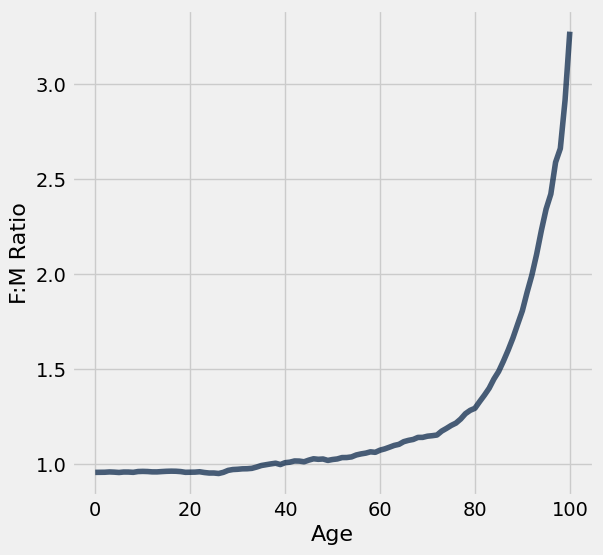

In [67]:
ratios.plot('Age', 'F:M Ratio')

### Try It 5: Zoom in 😊

1. Re-draw the ratio plot for ages **60 and up** only.

2. Around what age does the ratio start climbing steeply, and what does that mean in plain English?

In [ ]:
# 1. ratios for ages 60+


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Filter first, plot second; any table method chains into a plot.*

```python
# 1.
ratios.where('Age', are.above_or_equal_to(60)).plot('Age', 'F:M Ratio')
```

*2. The climb steepens through the 70s and 80s: at those ages women increasingly outnumber men, reflecting longer life expectancy.*

</details>

> **What do you see?** Near age 0 the ratio is just below 1 (slightly more baby boys are born), it hovers near 1 through mid-life, then climbs steeply after 75: women tend to live longer. One line plot, three demographic stories. 📈

---
> **Today's takeaway:** review done, you can now read, clean, filter, and combine columns on real data. Homework 3 leans on exactly these moves.

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### Minimal template — ratio of two groups
```python
a = t.where('group', 1).column('value')
b = t.where('group', 2).column('value')
Table().with_columns('x', xs, 'ratio', b / a).plot('x', 'ratio')
```